# 09 - Beyond conjugacy: Monte Carlo and Metropolis

**Goal.** Handle posteriors that have no closed form. We make Monte Carlo
integration precise, derive and implement the Metropolis algorithm from scratch, learn
to tune it and to diagnose whether it worked, and use it on a two-parameter logistic
regression. The course ends with a map of where to go next.

## 1. Monte Carlo integration

Every posterior summary is an expectation: a mean is $\mathbb E[\theta\mid y]$, a
probability is $\mathbb E[I_{\{\theta\in A\}}\mid y]$, a predictive density is
$\mathbb E[p(\tilde y\mid\theta)\mid y]$. Given $S$ independent draws
$\theta^{(1)},\dots,\theta^{(S)}$ from the posterior,
$$ \mathbb E[g(\theta)\mid y] \approx \frac1S\sum_{s=1}^S g\big(\theta^{(s)}\big), $$
and by the central limit theorem (chapter 02) the error is approximately normal with
standard deviation $\mathrm{sd}(g(\theta))/\sqrt S$. The error shrinks like
$1/\sqrt S$ **whatever the dimension of $\theta$**, which is why sampling beats grids
in many dimensions. We have been using this since chapter 05. The plot checks the
rate on the A/B test, where the exact answer is known.

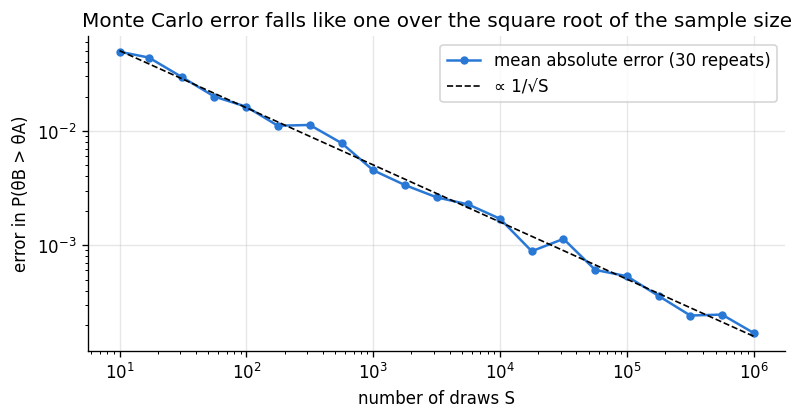

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (7.5, 3.4), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
PRIOR, LIK, POST = "#8a949e", "#eb6834", "#2a78d6"
rng = np.random.default_rng(9)

postA, postB = stats.beta(29, 241), stats.beta(44, 236)   # the A/B posteriors of chapter 05
exact = integrate.quad(lambda t: postA.pdf(t) * postB.sf(t), 0, 1)[0]
sizes = np.logspace(1, 6, 21).astype(int)
err = [np.mean([abs((postB.rvs(S, random_state=rng) > postA.rvs(S, random_state=rng)).mean() - exact)
                for _ in range(30)]) for S in sizes]
plt.loglog(sizes, err, "o-", color=POST, ms=4, label="mean absolute error (30 repeats)")
plt.loglog(sizes, 0.8 * np.sqrt(exact * (1 - exact) / sizes), "--", color="k", lw=1, label="∝ 1/√S")
plt.xlabel("number of draws S"); plt.ylabel("error in P(θB > θA)")
plt.title("Monte Carlo error falls like one over the square root of the sample size")
plt.legend(); plt.show()

## 2. When there is no formula

Conjugate models are the exception. Change the prior to one that is not conjugate, or
the likelihood to anything more realistic, and the posterior is known only up to its
constant:
$$ p(\theta\mid y) = \frac{q(\theta)}{Z},\qquad q(\theta) = p(y\mid\theta)\,p(\theta)\ \text{(easy to evaluate)},\qquad Z = \int q(\theta)\,\mathrm d\theta\ \text{(hard).} $$
We cannot sample it directly, and grids fail beyond a few dimensions. **Markov chain
Monte Carlo** (MCMC) produces samples using only evaluations of $q$.

**Example: a robust prior.** Back to measuring a quantity $\mu$ with known noise
$\sigma = 1$. Our prior guess is $\mu\approx0$, but we want a prior that gives way
gracefully if the data disagree strongly, so we use a heavy-tailed Cauchy prior
($t$ with 1 degree of freedom) instead of a normal. Five measurements average around
4. Normal likelihood times Cauchy prior is not a known distribution. It is one
dimensional, so a grid gives the exact answer to check the sampler against.

## 3. The Metropolis algorithm

Build a random walk whose long-run distribution is the posterior [1]:

1. Start at some $\theta^{(0)}$.
2. At step $s$, **propose** $\theta^* = \theta^{(s)} + \varepsilon$ with
   $\varepsilon\sim$ Normal$(0, \delta^2)$ (a symmetric proposal; $\delta$ is the step size).
3. **Accept** with probability $\min\big(1,\ q(\theta^*)/q(\theta^{(s)})\big)$: set
   $\theta^{(s+1)} = \theta^*$. Otherwise **stay**: $\theta^{(s+1)} = \theta^{(s)}$.

Moves uphill are always accepted; moves downhill are accepted in proportion to how
far down they go. Only the **ratio** $q(\theta^*)/q(\theta)$ is needed, so the unknown
$Z$ cancels. In code we work with $\log q$ to avoid underflow and accept when
$\log u < \log q(\theta^*) - \log q(\theta)$ for $u\sim$ Uniform$(0,1)$.

**Why it works.** Write $\pi$ for the posterior and $T(\theta\to\theta')$ for the
chance of moving from $\theta$ to $\theta'$. For $\theta\ne\theta'$ the proposal density
$g$ is symmetric, so
$$ \pi(\theta)\,T(\theta\to\theta') = \pi(\theta)\,g(\theta'-\theta)\,\min\Big(1,\frac{\pi(\theta')}{\pi(\theta)}\Big)
   = g(\theta'-\theta)\,\min\big(\pi(\theta),\pi(\theta')\big), $$
which is symmetric in $\theta$ and $\theta'$. This **detailed balance** means that if
the chain is distributed as $\pi$ at one step, it is still distributed as $\pi$ at the
next: $\pi$ is the stationary distribution. Under mild conditions the chain converges
to it from any starting point [2, 3]. Hastings generalised the rule to asymmetric
proposals by including the ratio $g(\theta\mid\theta^*)/g(\theta^*\mid\theta)$ [2].

The price is that successive draws are **correlated** and the first ones depend on
the start, so we discard an initial **burn-in** and need more draws than independent
sampling would.

acceptance rate 0.47
posterior mean: Metropolis 3.939, grid 3.944
sample mean 4.04; a Normal(0, 1) prior would give 3.37 (the Cauchy prior gives way to the data)


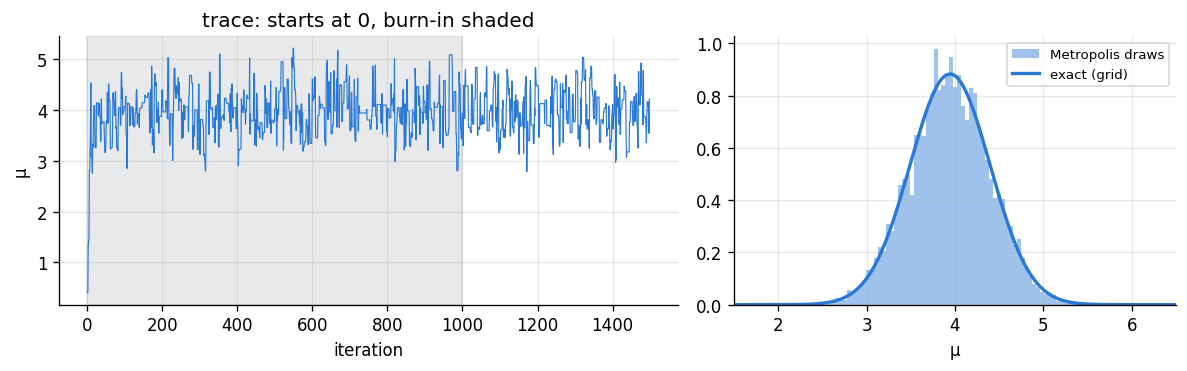

In [2]:
def metropolis(log_q, start, step, n_steps, rng):
    """Random-walk Metropolis. Works for scalar or vector parameters."""
    theta = np.atleast_1d(np.asarray(start, float))
    lq = log_q(theta)
    chain = np.empty((n_steps, theta.size))
    accepted = 0
    for s in range(n_steps):
        proposal = theta + step * rng.standard_normal(theta.size)
        lq_prop = log_q(proposal)
        if np.log(rng.random()) < lq_prop - lq:
            theta, lq = proposal, lq_prop
            accepted += 1
        chain[s] = theta
    return chain, accepted / n_steps

y = np.array([3.6, 4.9, 3.2, 4.4, 4.1])
sigma = 1.0
def log_q(mu):                                    # log likelihood + log Cauchy prior, constants dropped
    mu = mu[0]
    return -0.5 * np.sum((y - mu) ** 2) / sigma**2 - np.log1p(mu**2)

chain, acc = metropolis(log_q, start=0.0, step=1.0, n_steps=20_000, rng=rng)
draws = chain[1000:, 0]                           # discard burn-in

grid = np.linspace(-2, 8, 4001)
dens = np.exp([log_q(np.array([g])) for g in grid]); dens /= dens.sum() * (grid[1] - grid[0])
print(f"acceptance rate {acc:.2f}")
print(f"posterior mean: Metropolis {draws.mean():.3f}, grid {np.sum(grid * dens) * (grid[1] - grid[0]):.3f}")
print(f"sample mean {y.mean():.2f}; a Normal(0, 1) prior would give {len(y) * y.mean() / (len(y) + 1):.2f} "
      "(the Cauchy prior gives way to the data)")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2), gridspec_kw=dict(width_ratios=[1.4, 1]))
ax[0].plot(chain[:1500, 0], color=POST, lw=0.7); ax[0].axvspan(0, 1000, color=PRIOR, alpha=0.2)
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("μ"); ax[0].set_title("trace: starts at 0, burn-in shaded")
ax[1].hist(draws, bins=80, density=True, color=POST, alpha=0.45, label="Metropolis draws")
ax[1].plot(grid, dens, color=POST, lw=2, label="exact (grid)")
ax[1].set_xlim(1.5, 6.5); ax[1].set_xlabel("μ"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Tuning the step size

The step size $\delta$ controls how fast the chain explores:

- **too small**: almost every proposal is accepted, but each moves a tiny distance, so the
  chain crawls and successive draws are nearly identical;
- **too large**: proposals mostly land in low-probability regions and are rejected, so the
  chain sits still for long stretches;
- **about right**: for a one-dimensional roughly normal target, an acceptance rate
  around 40-45% is near optimal, falling towards 23% in high dimensions [4].

Correlation is measured by the **effective sample size** (ESS): the number of
independent draws that would give the same Monte Carlo error,
$$ \text{ESS} = \frac{S}{1+2\sum_{k\ge1}\rho_k}, $$
where $\rho_k$ is the autocorrelation of the chain at lag $k$. We estimate it by
summing the autocorrelations until they first drop below zero.

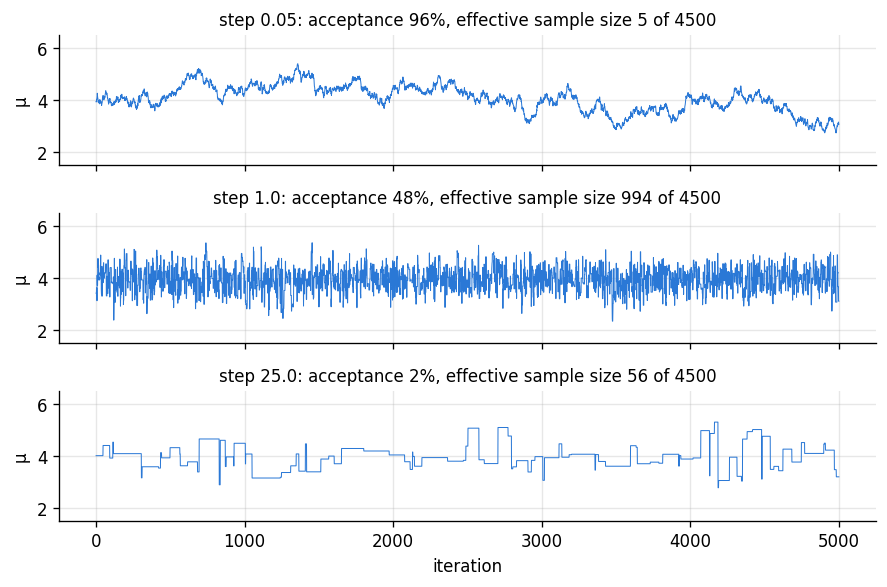

In [3]:
def ess(x):
    x = x - x.mean()
    acf = np.correlate(x, x, "full")[x.size - 1:] / (x.var() * x.size)
    neg = np.nonzero(acf[1:] < 0)[0]
    first_neg = neg[0] + 1 if neg.size else acf.size
    return x.size / (1 + 2 * acf[1:first_neg].sum())

fig, ax = plt.subplots(3, 1, figsize=(7.5, 5), sharex=True)
for a, step in zip(ax, [0.05, 1.0, 25.0]):
    c, acc = metropolis(log_q, 4.0, step, 5000, rng)
    a.plot(c[:, 0], color=POST, lw=0.6)
    a.set_ylabel("μ"); a.set_ylim(1.5, 6.5)
    a.set_title(f"step {step}: acceptance {acc:.0%}, effective sample size {ess(c[500:, 0]):.0f} of 4500",
                fontsize=10)
ax[-1].set_xlabel("iteration"); plt.tight_layout(); plt.show()

## 5. A two-parameter example: logistic regression

Golfers putt from different distances. For each distance (in feet) we record the
number of attempts and successes. The probability of success falls with distance,
which we model with **logistic regression**:
$$ y_j\sim\text{Binomial}(n_j, p_j),\qquad \log\frac{p_j}{1-p_j} = a + b\,x_j, $$
with weakly informative priors $a\sim$ Normal$(0, 5^2)$ and $b\sim$ Normal$(0, 1)$. No
conjugate prior exists for this likelihood. (The data are simulated from $a = 2.5$,
$b = -0.25$.)

Two practical points:

- **Run several chains** from dispersed starting points. If they end up exploring the
  same region, that is evidence they have converged; if not, something is wrong.
- **$\hat R$** (the Gelman-Rubin statistic) compares the variance between chains with
  the variance within chains [5]. Values close to 1 (below about 1.01 by current
  advice [6]) indicate agreement.

acceptance rates: 0.43, 0.42, 0.42, 0.43
a: posterior mean   2.723, 95% interval (2.254, 3.201), R-hat 1.0013, ESS about 894
b: posterior mean  -0.255, 95% interval (-0.296, -0.215), R-hat 1.0022, ESS about 900


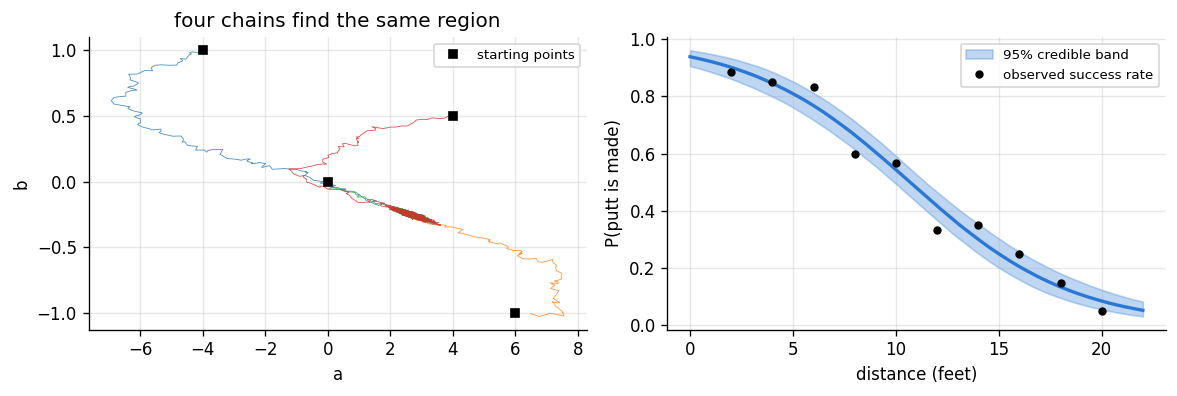

In [4]:
dist = np.arange(2, 21, 2).astype(float)
attempts = np.full(dist.size, 60)
made = rng.binomial(attempts, 1 / (1 + np.exp(-(2.5 - 0.25 * dist))))

def log_q2(params):
    a, b = params
    eta = a + b * dist
    loglik = np.sum(made * eta - attempts * np.logaddexp(0, eta))
    return loglik - a**2 / (2 * 5**2) - b**2 / 2

starts = [(-4, 1), (6, -1), (0, 0), (4, 0.5)]
chains = [metropolis(log_q2, s, np.array([0.15, 0.015]), 12_000, rng) for s in starts]
print("acceptance rates:", ", ".join(f"{acc:.2f}" for _, acc in chains))
kept = np.array([c[2000:] for c, _ in chains])                        # chains x draws x 2

def rhat(x):                                                          # x: chains x draws
    m, n_ = x.shape
    B = n_ * x.mean(axis=1).var(ddof=1)
    W = x.var(axis=1, ddof=1).mean()
    return np.sqrt(((n_ - 1) / n_ * W + B / n_) / W)

for j, name in enumerate(["a", "b"]):
    allj = kept[:, :, j].ravel()
    print(f"{name}: posterior mean {allj.mean():7.3f}, 95% interval ({np.quantile(allj, 0.025):.3f}, "
          f"{np.quantile(allj, 0.975):.3f}), R-hat {rhat(kept[:, :, j]):.4f}, "
          f"ESS about {sum(ess(kept[c, :, j]) for c in range(len(starts))):.0f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for c, _ in chains:
    ax[0].plot(c[:3000, 0], c[:3000, 1], lw=0.5, alpha=0.8)
ax[0].plot(*np.array(starts).T, "ks", ms=5, label="starting points")
ax[0].set_xlabel("a"); ax[0].set_ylabel("b"); ax[0].set_title("four chains find the same region"); ax[0].legend(fontsize=8)
xs = np.linspace(0, 22, 200)
draws2 = kept.reshape(-1, 2)[::20]
curves = 1 / (1 + np.exp(-(draws2[:, :1] + draws2[:, 1:] * xs)))
ax[1].fill_between(xs, *np.quantile(curves, [0.025, 0.975], axis=0), color=POST, alpha=0.3, label="95% credible band")
ax[1].plot(xs, np.median(curves, axis=0), color=POST, lw=2)
ax[1].plot(dist, made / attempts, "o", color="k", ms=4, label="observed success rate")
ax[1].set_xlabel("distance (feet)"); ax[1].set_ylabel("P(putt is made)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

All four chains agree ($\hat R\approx 1$), but notice the effective sample size:
about 900 out of 40,000 draws. The posterior of $(a,b)$ is a long, thin diagonal
ridge (a steeper slope is compensated by a larger intercept), and a random walk
with independent steps in $a$ and $b$ can only shuffle slowly along it. Centring the
distance, or a proposal shaped like the posterior, fixes this; the gradient-based
samplers below handle it automatically.

## 6. Where to go next

Random-walk Metropolis is the simplest MCMC algorithm and the one to understand
first. Practical work uses its descendants:

- **Gibbs sampling** [7, 8] draws each parameter in turn from its conditional posterior
  given the others. When those conditionals are known distributions, as in the
  normal-inverse-gamma model of chapter 06, no tuning is needed.
- **Hamiltonian Monte Carlo** uses the gradient of $\log q$ to make long, informed
  moves, and its adaptive version **NUTS** [9] tunes itself. It scales to models with
  thousands of parameters.
- **Probabilistic programming languages** let you write the model and get NUTS for
  free: **Stan** [10] and, in Python, **PyMC** [11]. The golf model above is about
  ten lines in either.
- **Hierarchical models** are the natural next topic: many related groups (players,
  schools, hospitals), each with its own parameter, sharing a common prior whose
  parameters are also learned. They are where Bayesian methods most clearly beat the
  alternatives, and they need exactly the MCMC tools of this chapter.

## You have finished the course

You can now take a question about an unknown quantity and answer it the Bayesian way:
choose a likelihood that describes how the data arise, choose a prior and check what
it implies, compute the posterior (exactly with a conjugate model, or by sampling),
and report it honestly, with intervals, probabilities of the statements that matter,
predictions, a model check, and a sensitivity analysis. The textbooks in chapter 00's
reference list, in particular McElreath [12] and Gelman et al. [13], are good next
steps.

### Exercises

1. Replace the Cauchy prior in the measurement example by Normal$(0, 1)$ and compare the
   posteriors. Then move the data to average 1 instead of 4. When does the choice
   between the two priors matter?
2. Show that the Metropolis acceptance rule in Section 3 satisfies detailed balance even
   when $\pi(\theta') > \pi(\theta)$. (Handle the two cases of the minimum separately.)
3. For the golf model, compute the posterior of the distance at which the success
   probability falls to 50%, $-a/b$, from the samples.
4. Start one golf chain far away, at $(20, 5)$, with only 3,000 steps. Compute $\hat R$
   with and without it. What does $\hat R$ detect?
5. Implement a Gibbs sampler for the normal model with unknown mean and variance of
   chapter 06, alternating $\mu\mid\sigma^2,y$ and $\sigma^2\mid\mu,y$ (derive the second
   one). Check it against the exact $t$ marginal of chapter 06.
6. Install PyMC and fit the golf model with NUTS. Compare its posterior means, run
   time and effective sample size with your Metropolis sampler.

## References

1. N. Metropolis, A. W. Rosenbluth, M. N. Rosenbluth, A. H. Teller, E. Teller. *Equation of state calculations by fast computing machines.* The Journal of Chemical Physics, 21(6):1087-1092, 1953. doi:10.1063/1.1699114
2. W. K. Hastings. *Monte Carlo sampling methods using Markov chains and their applications.* Biometrika, 57(1):97-109, 1970. doi:10.1093/biomet/57.1.97
3. C. P. Robert, G. Casella. *Monte Carlo Statistical Methods*, 2nd ed. Springer, 2004.
4. G. O. Roberts, A. Gelman, W. R. Gilks. *Weak convergence and optimal scaling of random walk Metropolis algorithms.* The Annals of Applied Probability, 7(1):110-120, 1997. doi:10.1214/aoap/1034625254
5. A. Gelman, D. B. Rubin. *Inference from iterative simulation using multiple sequences.* Statistical Science, 7(4):457-472, 1992. doi:10.1214/ss/1177011136
6. A. Vehtari, A. Gelman, D. Simpson, B. Carpenter, P.-C. Bürkner. *Rank-normalization, folding, and localization: an improved R-hat for assessing convergence of MCMC.* Bayesian Analysis, 16(2):667-718, 2021. doi:10.1214/20-BA1221
7. S. Geman, D. Geman. *Stochastic relaxation, Gibbs distributions, and the Bayesian restoration of images.* IEEE Transactions on Pattern Analysis and Machine Intelligence, 6(6):721-741, 1984. doi:10.1109/TPAMI.1984.4767596
8. A. E. Gelfand, A. F. M. Smith. *Sampling-based approaches to calculating marginal densities.* Journal of the American Statistical Association, 85(410):398-409, 1990. doi:10.1080/01621459.1990.10476213
9. M. D. Hoffman, A. Gelman. *The No-U-Turn Sampler: adaptively setting path lengths in Hamiltonian Monte Carlo.* Journal of Machine Learning Research, 15:1593-1623, 2014.
10. B. Carpenter et al. *Stan: a probabilistic programming language.* Journal of Statistical Software, 76(1), 2017. doi:10.18637/jss.v076.i01
11. O. Abril-Pla et al. *PyMC: a modern and comprehensive probabilistic programming framework in Python.* PeerJ Computer Science, 9:e1516, 2023. doi:10.7717/peerj-cs.1516
12. R. McElreath. *Statistical Rethinking*, 2nd ed. CRC Press, 2020.
13. A. Gelman et al. *Bayesian Data Analysis*, 3rd ed. CRC Press, 2013.